# Flight Delay Prediction

## 1. Setup

In [28]:
!pip install lightgbm

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

# Folders for saving outputs (these are what you'll send me for the report)
for folder in ['figures', 'results']:
    os.makedirs(folder, exist_ok=True)

## 2. Load the Data

In [30]:
flights = pd.read_csv('data/flights.csv', low_memory=False)
airlines = pd.read_csv('data/airlines.csv')
airports = pd.read_csv('data/airports.csv')

print('Flights shape:', flights.shape)
print('Airlines shape:', airlines.shape)
print('Airports shape:', airports.shape)
flights.head()

Flights shape: (5819079, 31)
Airlines shape: (14, 2)
Airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Attach the full airline name (airlines.csv maps IATA_CODE -> full name)
airlines = airlines.rename(columns={'AIRLINE': 'AIRLINE_NAME'})
flights = flights.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights[['AIRLINE', 'AIRLINE_NAME']].drop_duplicates().head()

,AIRLINE,AIRLINE_NAME
0,AS,Alaska Airlines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
5,DL,Delta Air Lines Inc.
6,NK,Spirit Air Lines


## 3. Exploratory Data Analysis

In [32]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 33 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [33]:
# Missing values per column
missing = flights.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
WEATHER_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
AIR_TIME                105071
ELAPSED_TIME            105071
ARRIVAL_DELAY           105071
ARRIVAL_TIME             92513
WHEELS_ON                92513
TAXI_IN                  92513
TAXI_OUT                 89047
WHEELS_OFF               89047
DEPARTURE_DELAY          86153
DEPARTURE_TIME           86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
dtype: int64

### Target creation & filtering

In [34]:
df = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)].copy()
df = df[df['ARRIVAL_DELAY'].notnull()]
print('After removing cancelled/diverted:', df.shape)

df['is_delayed'] = (df['ARRIVAL_DELAY'] > 15).astype(int)
print(df['is_delayed'].value_counts(normalize=True).round(3))

After removing cancelled/diverted: (5714008, 33)
is_delayed
0    0.821
1    0.179
Name: proportion, dtype: float64


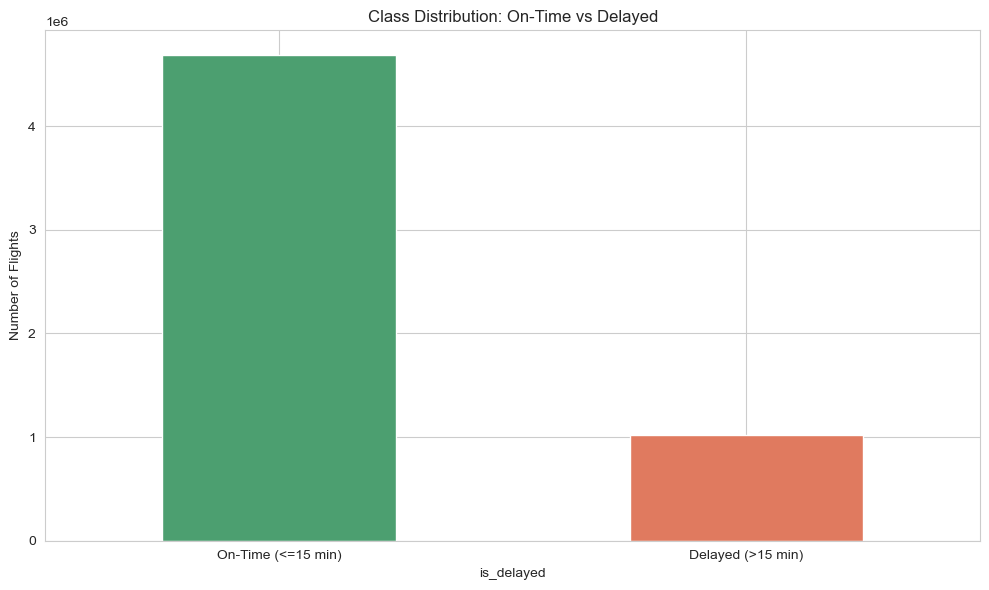

In [35]:
# Class distribution
plt.figure()
df['is_delayed'].value_counts().sort_index().plot(kind='bar', color=['#4C9F70', '#E07A5F'])
plt.title('Class Distribution: On-Time vs Delayed')
plt.xticks([0, 1], ['On-Time (<=15 min)', 'Delayed (>15 min)'], rotation=0)
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()

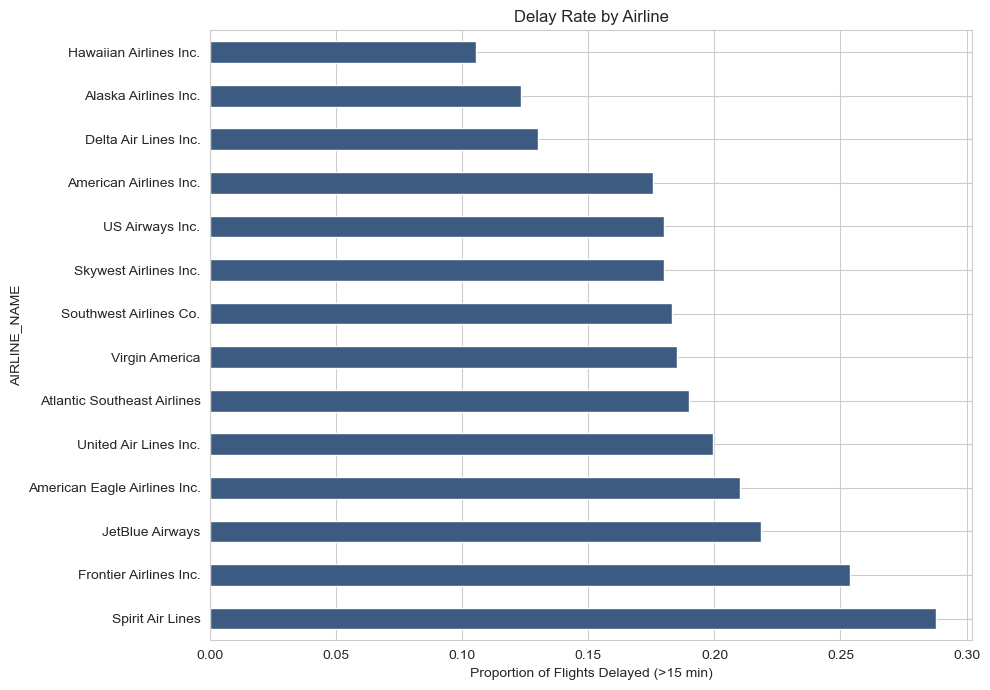

In [36]:
# Delay rate by airline
airline_delay = df.groupby('AIRLINE_NAME')['is_delayed'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
airline_delay.plot(kind='barh', color='#3D5A80')
plt.title('Delay Rate by Airline')
plt.xlabel('Proportion of Flights Delayed (>15 min)')
plt.tight_layout()
plt.savefig('figures/delay_by_airline.png', dpi=150)
plt.show()

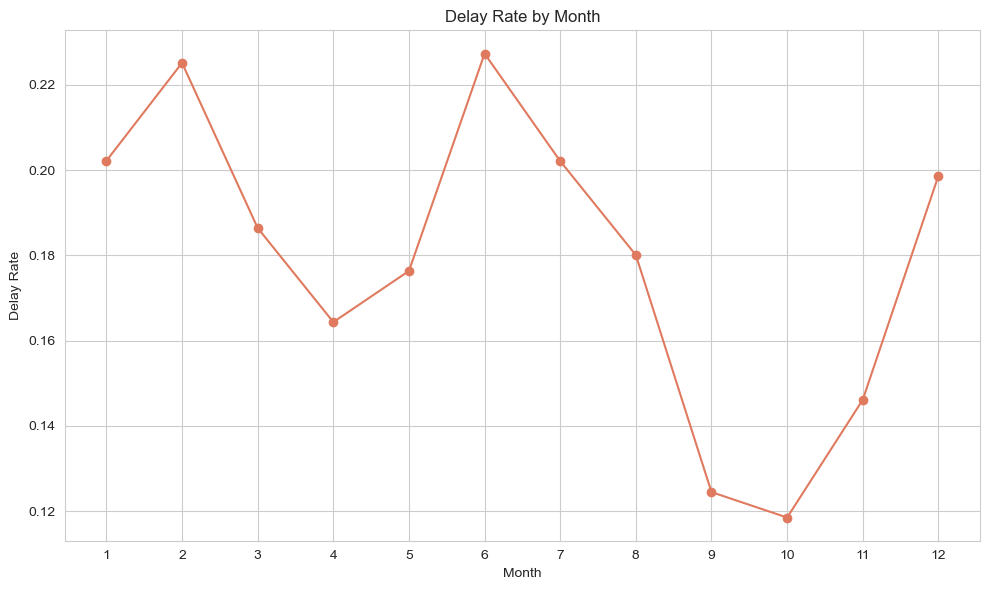

In [37]:
# Delay rate by month (seasonality)
month_delay = df.groupby('MONTH')['is_delayed'].mean()
plt.figure()
month_delay.plot(kind='line', marker='o', color='#E07A5F')
plt.title('Delay Rate by Month')
plt.xlabel('Month'); plt.ylabel('Delay Rate')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('figures/delay_by_month.png', dpi=150)
plt.show()

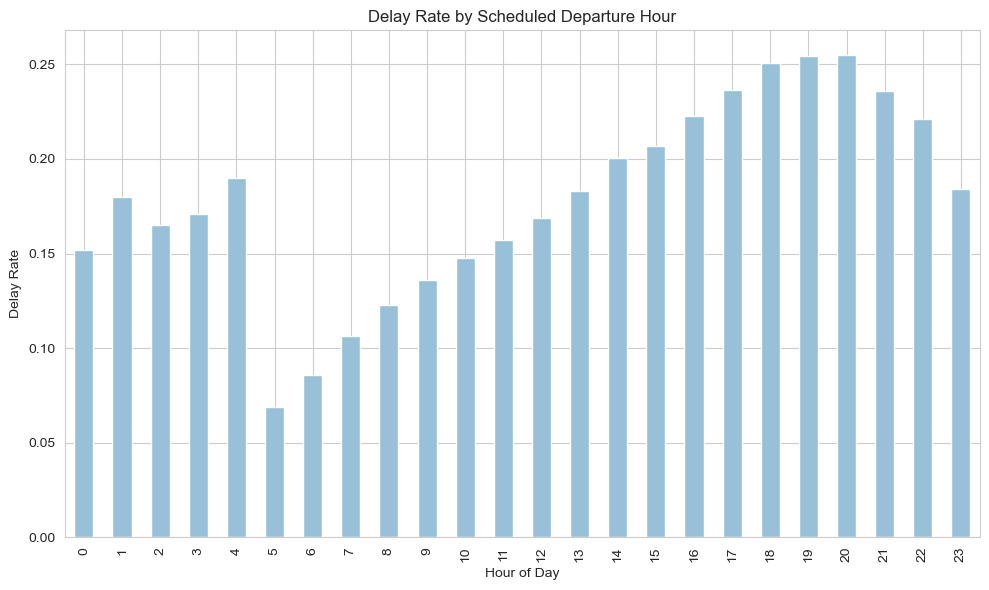

In [38]:
# Delay rate by scheduled departure hour
df['hour_of_day'] = df['SCHEDULED_DEPARTURE'] // 100
hour_delay = df.groupby('hour_of_day')['is_delayed'].mean()
plt.figure()
hour_delay.plot(kind='bar', color='#98C1D9')
plt.title('Delay Rate by Scheduled Departure Hour')
plt.xlabel('Hour of Day'); plt.ylabel('Delay Rate')
plt.tight_layout()
plt.savefig('figures/delay_by_hour.png', dpi=150)
plt.show()

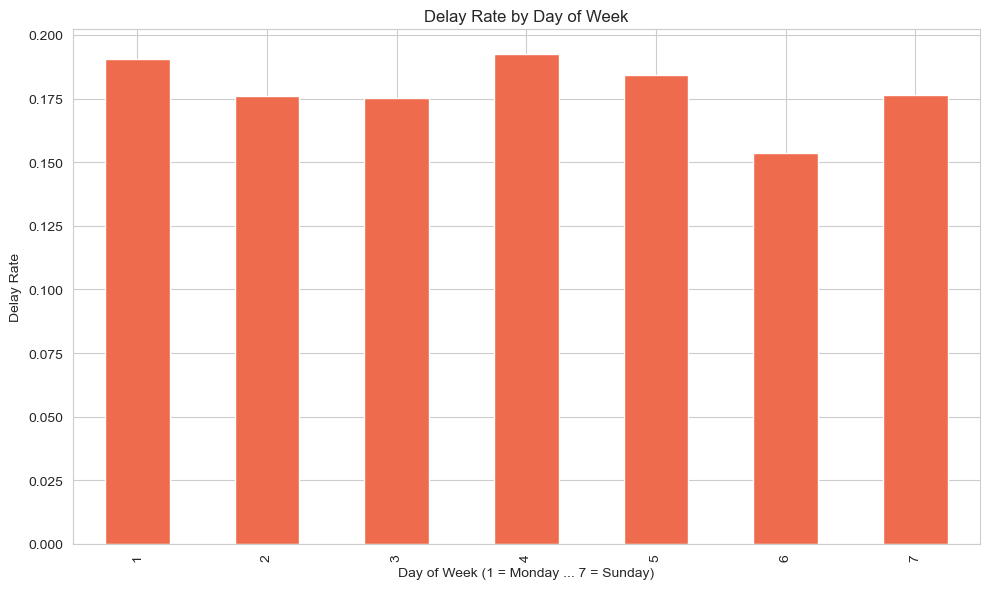

In [39]:
# Delay rate by day of week
dow_delay = df.groupby('DAY_OF_WEEK')['is_delayed'].mean()
plt.figure()
dow_delay.plot(kind='bar', color='#EE6C4D')
plt.title('Delay Rate by Day of Week')
plt.xlabel('Day of Week (1 = Monday ... 7 = Sunday)'); plt.ylabel('Delay Rate')
plt.tight_layout()
plt.savefig('figures/delay_by_dow.png', dpi=150)
plt.show()

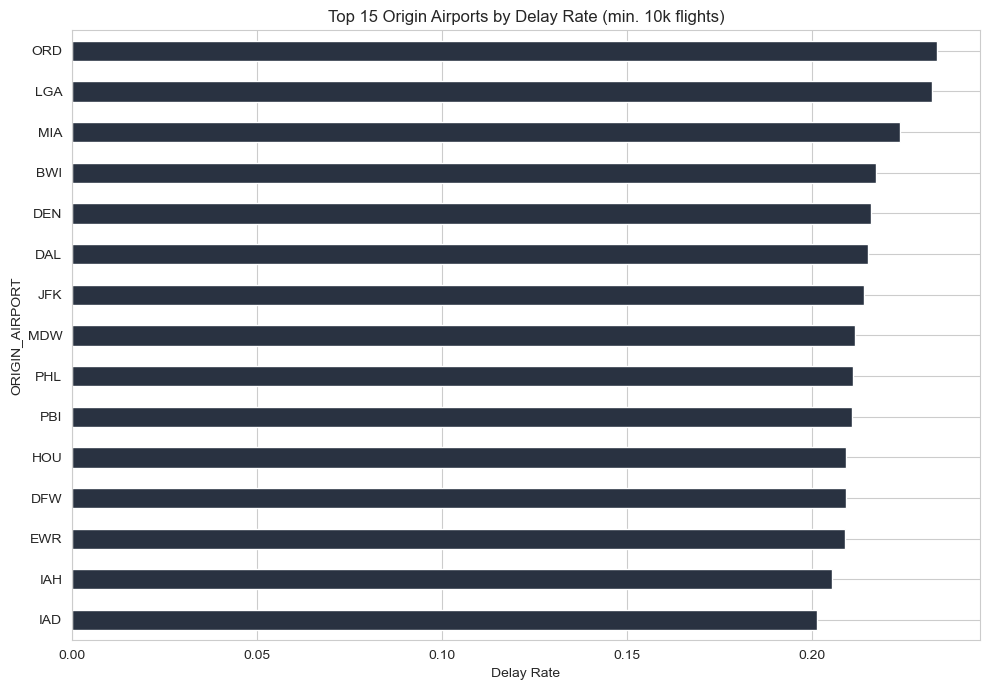

In [40]:
# Top 15 origin airports by delay rate (only busy ones, >10k flights)
airport_counts = df['ORIGIN_AIRPORT'].value_counts()
busy = airport_counts[airport_counts > 10000].index
airport_delay = (df[df['ORIGIN_AIRPORT'].isin(busy)]
                 .groupby('ORIGIN_AIRPORT')['is_delayed'].mean()
                 .sort_values(ascending=False).head(15))
plt.figure(figsize=(10, 7))
airport_delay.plot(kind='barh', color='#293241')
plt.gca().invert_yaxis()
plt.title('Top 15 Origin Airports by Delay Rate (min. 10k flights)')
plt.xlabel('Delay Rate')
plt.tight_layout()
plt.savefig('figures/delay_by_airport.png', dpi=150)
plt.show()

## 4. Sampling for Tractability

In [41]:
SAMPLE_SIZE = 600000  
if len(df) > SAMPLE_SIZE:
    df_model = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_model = df.copy()
print('Modeling sample shape:', df_model.shape)

Modeling sample shape: (600000, 35)


## 5. Feature Engineering

In [42]:
def time_of_day(hour):
    if 5 <= hour <= 11:  return 'Morning'
    if 12 <= hour <= 17: return 'Afternoon'
    if 18 <= hour <= 21: return 'Evening'
    return 'Night'

def season(month):
    if month in (12, 1, 2): return 'Winter'
    if month in (3, 4, 5):  return 'Spring'
    if month in (6, 7, 8):  return 'Summer'
    return 'Fall'

df_model['hour_of_day'] = df_model['SCHEDULED_DEPARTURE'] // 100
df_model['time_of_day'] = df_model['hour_of_day'].apply(time_of_day)
df_model['season']      = df_model['MONTH'].apply(season)
df_model['is_weekend']  = (df_model['DAY_OF_WEEK'] >= 6).astype(int)
df_model['SCHEDULED_TIME'] = df_model['SCHEDULED_TIME'].fillna(df_model['SCHEDULED_TIME'].median())
df_model[['hour_of_day', 'time_of_day', 'season', 'is_weekend']].head()

,hour_of_day,time_of_day,season,is_weekend
0,16,Afternoon,Summer,0
1,18,Evening,Fall,0
2,11,Morning,Fall,0
3,13,Afternoon,Fall,0
4,6,Morning,Fall,0


### Train/test split first, then target-encode airports

In [43]:
target = 'is_delayed'
y = df_model[target]

train_idx, test_idx = train_test_split(
    df_model.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
train = df_model.loc[train_idx].copy()
test  = df_model.loc[test_idx].copy()

# Historical delay rate per airport, computed on TRAIN ONLY
global_rate = train[target].mean()
origin_map = train.groupby('ORIGIN_AIRPORT')[target].mean()
dest_map   = train.groupby('DESTINATION_AIRPORT')[target].mean()

for d in (train, test):
    d['origin_delay_rate'] = d['ORIGIN_AIRPORT'].map(origin_map).fillna(global_rate)
    d['dest_delay_rate']   = d['DESTINATION_AIRPORT'].map(dest_map).fillna(global_rate)

print('Train:', train.shape, '| Test:', test.shape)

Train: (480000, 40) | Test: (120000, 40)


### Build two feature matrices

- **Base** = raw scheduling info only (for the ablation study)
- **Engineered** = base + time-of-day, season, weekend flag, and airport delay-rate features

In [44]:
base_numeric = ['MONTH', 'DAY_OF_WEEK', 'hour_of_day', 'DISTANCE', 'SCHEDULED_TIME']
base_cat     = ['AIRLINE']

eng_numeric  = base_numeric + ['is_weekend', 'origin_delay_rate', 'dest_delay_rate']
eng_cat      = ['AIRLINE', 'time_of_day', 'season']

def build_matrix(train, test, numeric, categorical):
    Xtr = pd.get_dummies(train[numeric + categorical], columns=categorical)
    Xte = pd.get_dummies(test[numeric + categorical], columns=categorical)
    Xtr, Xte = Xtr.align(Xte, join='left', axis=1, fill_value=0)  # match columns
    return Xtr, Xte

X_train_base, X_test_base = build_matrix(train, test, base_numeric, base_cat)
X_train_eng,  X_test_eng  = build_matrix(train, test, eng_numeric, eng_cat)

y_train = train[target]
y_test  = test[target]

print('Base feature count:      ', X_train_base.shape[1])
print('Engineered feature count:', X_train_eng.shape[1])

Base feature count:       19
Engineered feature count: 30


## 6. Evaluation Helper

In [45]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
    }

results = []

## 7. Baseline 1 — Logistic Regression

In [46]:
scaler = StandardScaler()
X_train_eng_scaled = scaler.fit_transform(X_train_eng)
X_test_eng_scaled  = scaler.transform(X_test_eng)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_eng_scaled, y_train)
lr_pred = lr.predict(X_test_eng_scaled)

res = evaluate('Logistic Regression', y_test, lr_pred)
results.append(res)
print(res)
print(classification_report(y_test, lr_pred))

{'Model': 'Logistic Regression', 'Accuracy': 0.592, 'Precision': 0.2476, 'Recall': 0.627, 'F1': 0.355}
              precision    recall  f1-score   support

           0       0.88      0.58      0.70     98508
           1       0.25      0.63      0.36     21492

    accuracy                           0.59    120000
   macro avg       0.56      0.61      0.53    120000
weighted avg       0.76      0.59      0.64    120000



## 8. Baseline 2 — Random Forest

In [47]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_eng, y_train)
rf_pred = rf.predict(X_test_eng)

res = evaluate('Random Forest', y_test, rf_pred)
results.append(res)
print(res)
print(classification_report(y_test, rf_pred))

{'Model': 'Random Forest', 'Accuracy': 0.7392, 'Precision': 0.3046, 'Recall': 0.3557, 'F1': 0.3282}
              precision    recall  f1-score   support

           0       0.85      0.82      0.84     98508
           1       0.30      0.36      0.33     21492

    accuracy                           0.74    120000
   macro avg       0.58      0.59      0.58    120000
weighted avg       0.76      0.74      0.75    120000



## 9. Final Model — LightGBM

In [48]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=400, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=RANDOM_STATE,
)

lgb_clf.fit(X_train_eng, y_train)
lgb_pred = lgb_clf.predict(X_test_eng)

res = evaluate('LightGBM', y_test, lgb_pred)
results.append(res)
print(res)
print(classification_report(y_test, lgb_pred))

[LightGBM] [Info] Number of positive: 85970, number of negative: 394030
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022348 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
{'Model': 'LightGBM', 'Accuracy': 0.6259, 'Precision': 0.2692, 'Recall': 0.635, 'F1': 0.3781}
              precision    recall  f1-score   support

           0       0.89      0.62      0.73     98508
           1       0.27      0.64      0.38     21492

    accuracy                           0.63    120000
   macro avg       0.58      0.63      0.56    120000
weighted avg       0.78      0.63      0.67    120000



## 10. Model Comparison

In [49]:
results_df = pd.DataFrame(results).set_index('Model')
results_df.to_csv('results/model_comparison.csv')
results_df

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.5920,0.2476,0.6270,0.3550
Random Forest,0.7392,0.3046,0.3557,0.3282
LightGBM,0.6259,0.2692,0.6350,0.3781


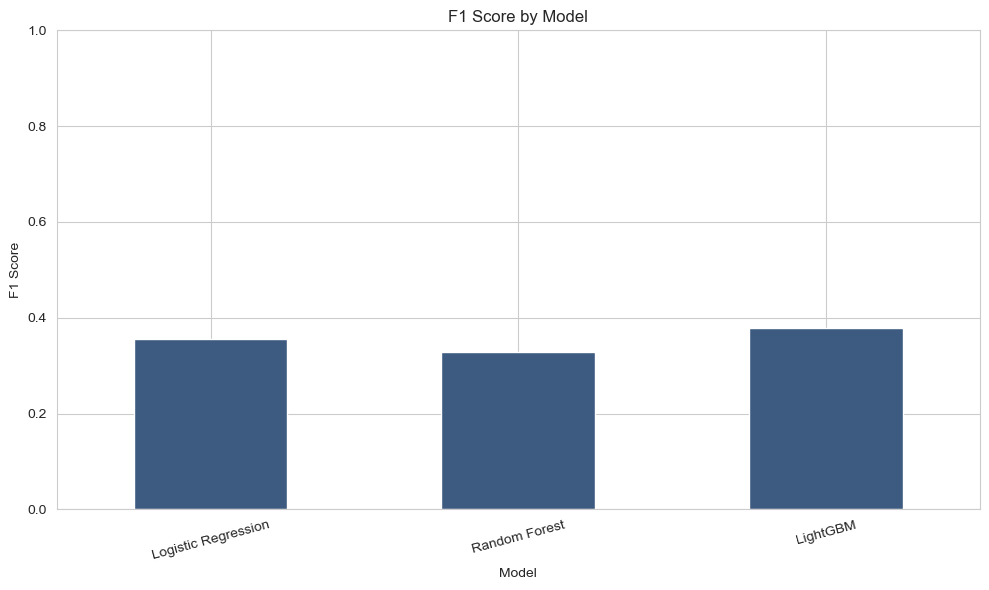

In [50]:
plt.figure()
results_df['F1'].plot(kind='bar', color='#3D5A80')
plt.title('F1 Score by Model')
plt.ylabel('F1 Score'); plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()

## 11. Ablation Study

In [51]:
lgb_base = lgb.LGBMClassifier(
    n_estimators=400, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=RANDOM_STATE)
lgb_base.fit(X_train_base, y_train)
base_pred = lgb_base.predict(X_test_base)

ablation = pd.DataFrame([
    evaluate('LightGBM (base features)', y_test, base_pred),
    evaluate('LightGBM (+ engineered features)', y_test, lgb_pred),
]).set_index('Model')
ablation.to_csv('results/ablation.csv')
ablation

[LightGBM] [Info] Number of positive: 85970, number of negative: 394030
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012175 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,Accuracy,Precision,Recall,F1
Model,,,,
LightGBM (base features),0.6186,0.2641,0.6323,0.3726
LightGBM (+ engineered features),0.6259,0.2692,0.6350,0.3781


## 12. Feature Importance

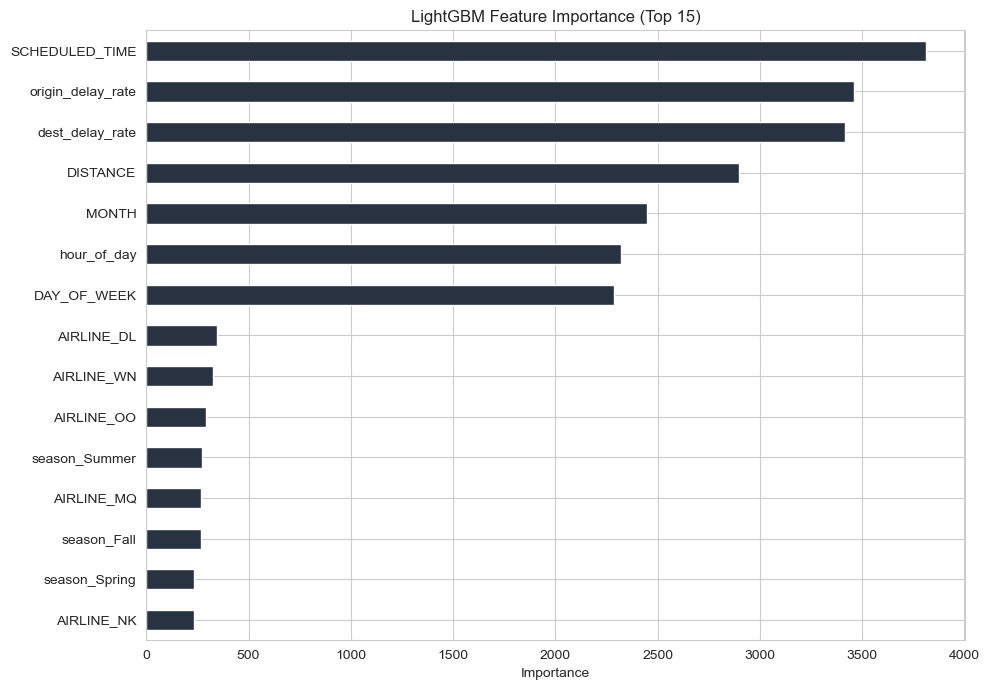

SCHEDULED_TIME       3811
origin_delay_rate    3461
dest_delay_rate      3418
DISTANCE             2898
MONTH                2448
hour_of_day          2320
DAY_OF_WEEK          2288
AIRLINE_DL            348
AIRLINE_WN            325
AIRLINE_OO            293
season_Summer         272
AIRLINE_MQ            269
season_Fall           268
season_Spring         236
AIRLINE_NK            235
dtype: int32

In [52]:
importances = pd.Series(lgb_clf.feature_importances_, index=X_train_eng.columns)
top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top.plot(kind='barh', color='#293241')
plt.gca().invert_yaxis()
plt.title('LightGBM Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150)
plt.show()
top

## 13. Hyperparameter Sensitivity (num_leaves)

[LightGBM] [Info] Number of positive: 85970, number of negative: 394030
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 85970, number of negative: 394030
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018644 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1061
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.00000

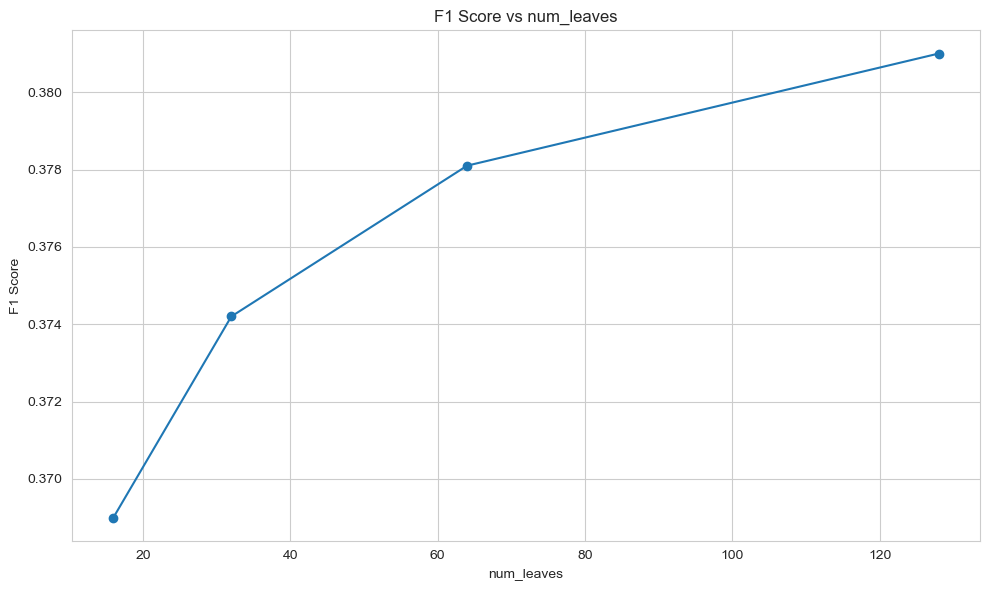

,num_leaves,F1,Accuracy
0,16,0.3690,0.6106
1,32,0.3742,0.6182
2,64,0.3781,0.6259
3,128,0.3810,0.6376


In [53]:
sens = []
for nl in [16, 32, 64, 128]:
    m = lgb.LGBMClassifier(
        n_estimators=400, num_leaves=nl, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_STATE)
    m.fit(X_train_eng, y_train)
    p = m.predict(X_test_eng)
    sens.append({'num_leaves': nl,
                 'F1': round(f1_score(y_test, p), 4),
                 'Accuracy': round(accuracy_score(y_test, p), 4)})

sens_df = pd.DataFrame(sens)
sens_df.to_csv('results/hyperparam_sensitivity.csv', index=False)

plt.figure()
plt.plot(sens_df['num_leaves'], sens_df['F1'], marker='o')
plt.title('F1 Score vs num_leaves')
plt.xlabel('num_leaves'); plt.ylabel('F1 Score')
plt.tight_layout()
plt.savefig('figures/hyperparam_sensitivity.png', dpi=150)
plt.show()
sens_df

## 14. Confusion Matrix (Final Model)

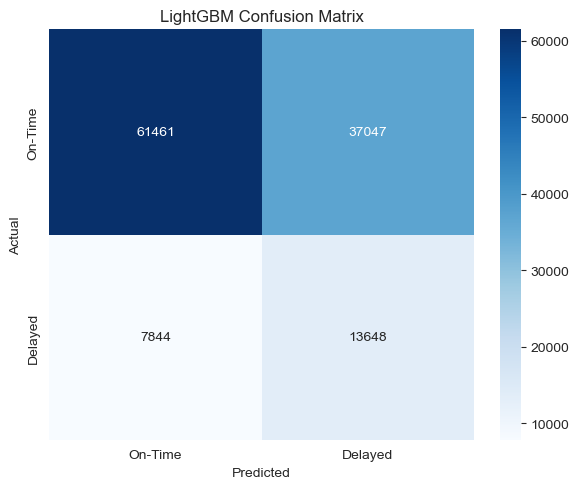

In [54]:
cm = confusion_matrix(y_test, lgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
plt.title('LightGBM Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()